# CS 3110/5110: Data Privacy

## In-Class Exercise, week of 9/14/2026


In [14]:
# Load the data and libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

adult = pd.read_csv(
    "https://github.com/jnear/cs3110-data-privacy/raw/main/homework/adult_with_pii.csv"
)

In [15]:
df = adult[["Education", "Marital Status", "Target"]]
df.head(10)

,Education,Marital Status,Target
0,Bachelors,Never-married,<=50K
1,Bachelors,Married-civ-spouse,<=50K
2,HS-grad,Divorced,<=50K
3,11th,Married-civ-spouse,<=50K
4,Bachelors,Married-civ-spouse,<=50K
5,Masters,Married-civ-spouse,<=50K
6,9th,Married-spouse-absent,<=50K
7,HS-grad,Married-civ-spouse,>50K
8,Masters,Never-married,>50K
9,Bachelors,Married-civ-spouse,>50K


## Question 6

Imagine the column `Target` is _not_ a quasi-identifier, and we generalize the dataset to achieve $k$-Anonymity for $k=2$ as follows:

- Replace each education level below "HS Grad" with `< HS` and others with `>= HS`
- Replace marital status with `Married` and `Not Married`
- Delete rows as required to achieve $k$-anonymity for $k=2$

For which rows is a homogeneity attack possible, and why?


If any group contains only a single Target (the column), then a homogeneity
attack is possible.

For k = 2, the combo <HS and Married has only one target value.


## Question 7

Write code to generalize the `Zip` column in the adult dataset.


In [16]:
# count how many times each unique zip code appears in the adult dataset
import pandas as pd

# load the adult dataset
adult_df = adult

# count how many times each unique zip code appears
zip_code_counts = adult_df["Zip"].value_counts()
print(zip_code_counts)

Zip
69315    5
32527    5
35283    5
39163    5
33401    4
        ..
52272    1
66892    1
94735    1
8213     1
86153    1
Name: count, Length: 27791, dtype: int64


In [17]:
# l is the number of rightmost digits to replace with zeros
def generalize_zip(zip, l):
    new_zip = int(zip / 10**l) * 10**l
    return new_zip

In [18]:
# This is an example of applying the generalize_zip function to the "Zip" column
# of the adult dataset (with the last 2 digits of the zip code generalized)
adult["Zip"].apply(lambda zip: generalize_zip(zip, 2))

0        64100
1        61500
2        95600
3        25500
4        75300
         ...  
32556    41300
32557    94700
32558    49600
32559     8200
32560    86100
Name: Zip, Length: 32561, dtype: int64

In [19]:
# Test cases
assert generalize_zip(47401, 0) == 47401
assert generalize_zip(47401, 1) == 47400
assert generalize_zip(47401, 2) == 47400
assert generalize_zip(47401, 3) == 47000
assert generalize_zip(47401, 4) == 40000
assert generalize_zip(47401, 5) == 0

## Question 1

Write a _counting query_ to determine whether or not Karrie Trusslove's age is 39.


In [20]:
def karrie_query():
    kerry = adult[(adult["Name"] == "Karrie Trusslove") & (adult["Age"] == 39)]
    # if this returns 1, then we know Karrie of age 39 is in the dataset
    # if this returns 0, then we know Karrie of age 39 is not in the dataset

    return len(kerry)

In [21]:
# TEST CASE
# The result of this query allows me to conculde something from the dataset WITH
# ABSOLUTE CERTAINTY.
assert karrie_query() == 1

## Question 2

Add Laplace noise to the counting query you wrote in the last question to ensure differential privacy for $\epsilon = 1.0$.


In [22]:
# Goal is to add random noise to the 0 or 1 I get from karrie_query()
# to obscure whether the true answer is 0 or 1.

# This prevents the adversary from having any certainty in their attempt to
# learn Karrie's age.

# Problem: This means we return the *wrong answer*
# Another Problem: we need to prevent the adversary from running this multiple
# times because that would reveal the true answer with higher certainty as they
# run it more and more.

# Counting queries always have a sensitivity of 1. Which means the results
# change by at most 1 when a single individual's data is added or removed.

# Tradeoff: lower epsilon = more privacy but more noise (less utility)
#           high epsilon  = less privacy but less noise (more utility)


epsilon = 1  # privacy parameter, can be adjusted based on desired tradeoff


def dp_karrie_query():
    original_result = karrie_query()

    noise = np.random.laplace(loc=0, scale=1 / epsilon)

    # add random noise to the original result
    return original_result + noise

In [23]:
dp_karrie_query()

# Uniform noise does not work! Because it gives a concrete boundary that can
# tell the adversary that the original number is within a fixed range. While
# mechanisms like Laplace and Gaussian have infinite output ranges.

1.882513924930274

In [24]:
# TEST CASE

q2_runs = [dp_karrie_query() for _ in range(100)]
noise_runs = [np.random.laplace(loc=1, scale=1 / epsilon) for _ in range(100)]

assert stats.wasserstein_distance(q2_runs, noise_runs) < 1

## Question 3

In 2-4 sentences, describe how `dp_karrie_query` protects Karrie's privacy.


- The original query is adversarially constructed to violate Karrie's privacy.
- The answer is 1 if Karrie is 39 and 0 otherwise.
- The noise introduces uncertainty for an adversary who wants to guess whether
  the answer was 0 or 1 based on the Differential Privacy result.
- More noise (lower epsilon, higher scale parameter) makes this uncertainty greater.
- The noise (and thus the uncertainty) is independant of the data (and anything
  else in the world). So the adversary can't undo the noise using auxilliary information.


## Question 4

Implement a function to construct an _empirical distribution_ over random samples from the Laplace distribution with location 0 and scale `scale`. Use 1000 samples.


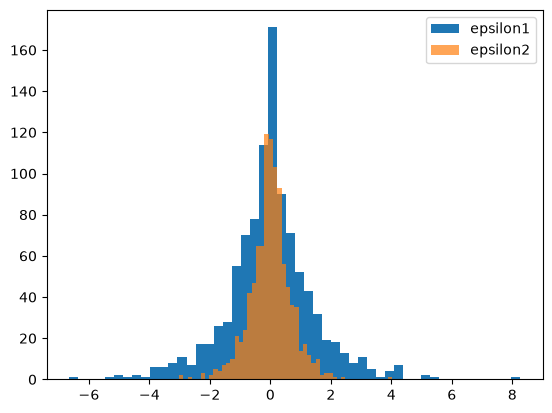

In [25]:
def empirical_dist_lap(scale):
    # Generate an empirical distribution by sampling from the Laplace distribution
    samples = [np.random.laplace(loc=0, scale=scale) for _ in range(1000)]
    return samples


epsilon1 = 1.0
epsilon2 = 2.0

plt.hist(empirical_dist_lap(1 / epsilon1), bins=50, label="epsilon1")
plt.hist(empirical_dist_lap(1 / epsilon2), bins=50, alpha=0.7, label="epsilon2")
plt.legend()

In [ ]:
# Does the extra noise prevent you from making useful inferences from the data?
# Depends on the question, the example used in class was "Are there a lot of
# people over the age of 50", in which case an answer of 6400 and 6500 would
# both give you the same amount of utility, while still allowing us to introduce
# a lot of noise to protect privacy.

## Question 5

Consider the program below.


In [ ]:
counting_query = lambda: 1

result_1 = counting_query() + np.random.laplace(loc=0, scale=1 / epsilon1)
result_2 = counting_query() + np.random.laplace(loc=0, scale=1 / epsilon2)
result_3 = counting_query() + np.random.laplace(loc=0, scale=1 / epsilon1)

print(result_1, result_2, result_3)

Write a function `total_epsilon` that returns the total privacy cost for this program.


In [ ]:
def total_epsilon():
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
# Placeholder for test case